# 07_Explainable_AI

In [2]:
pip install shap

  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 3.7 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 4.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import joblib
import shap
import pandas as pd

/Users/kool_koder_kaash/Desktop/tvs/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# load model and dataset
df = pd.read_csv("../data/processed/final_dataset.csv")

model = joblib.load("../models/catboost_residual.pkl")

In [8]:
target = "Target Sold Amount At Liquidation"

drop_cols = [
    "Agmt Id",
    target,
    "Sold Date",
    "Sold Date Month",
    "Sold Date Year",
    "Seizure Date",
    "Seizure Date Month",
    "Seizure Date Year",
    "OS Balance At Liquidation",
    "Asset Age Months At Seizure",
    "Months Spent In Yard",
    "Depreciation_Pct",
    "Recovery_Efficiency_Index",
    "LGD",
    "LGD_pct"
]

X = df.drop(columns=drop_cols, errors="ignore")

In [9]:
print(len(model.feature_names_))
print(len(X.columns))

32
32


In [10]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

print("SHAP calculated")

SHAP calculated


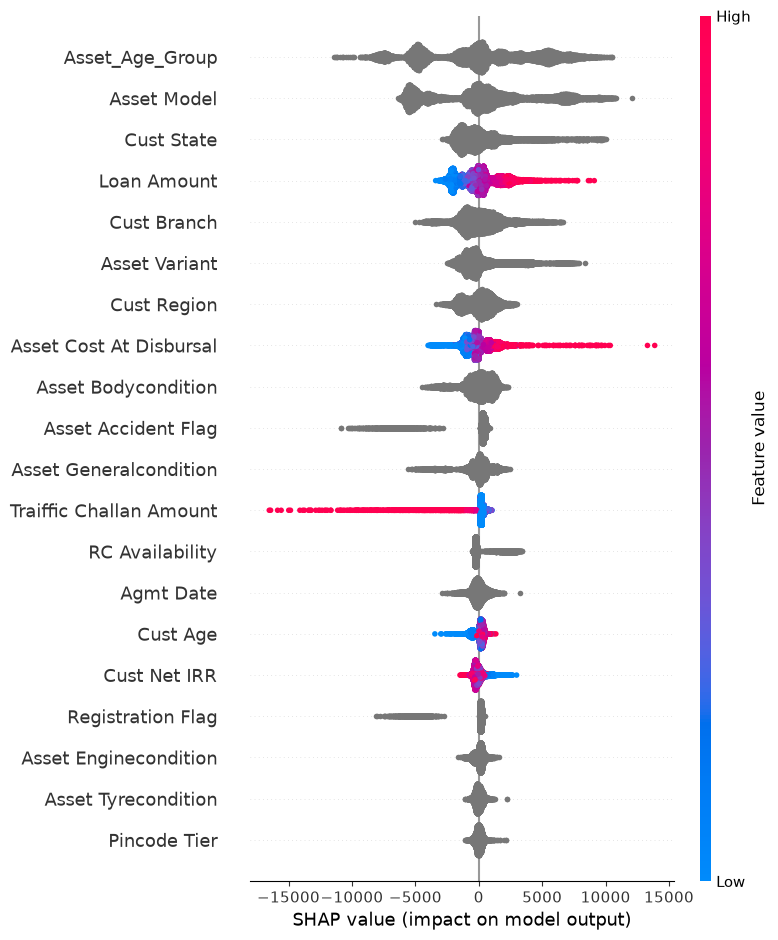

In [11]:
shap.summary_plot(shap_values, X)

In [12]:
X.dtypes

Cust Age                     int64
Cust Gender                    str
Cust Cibil Score             int64
Cust Employment Type           str
Cust Net Salary              int64
Coborrower Flag                str
App Score Risk                 str
Agmt Date                      str
Tenure                       int64
Cust Net IRR               float64
Cust Branch                    str
Cust Region                    str
Cust State                     str
Pincode Tier                   str
RC Availability                str
Registration Flag              str
Asset Disc Flag              int64
Asset Alloy Flag             int64
Asset Variant                  str
Asset Model                    str
Asset Fuel Type                str
Asset Cost At Disbursal      int64
Loan Amount                  int64
LTV                        float64
Asset Bodycondition            str
Asset Tyrecondition            str
Asset Generalcondition         str
Asset Enginecondition          str
Asset Accident Flag 

In [13]:
X["Agmt Date"] = pd.to_datetime(X["Agmt Date"]).astype("int64")

In [14]:
feature_imp = pd.DataFrame({
    "Feature": model.feature_names_,
    "Importance": model.get_feature_importance()
}).sort_values("Importance", ascending=False)

feature_imp.head(15)

,Feature,Importance
19,Asset Model,18.670595
31,Asset_Age_Group,11.443260
12,Cust State,7.681151
10,Cust Branch,6.906634
21,Asset Cost At Disbursal,6.620870
22,Loan Amount,5.377578
18,Asset Variant,5.201955
11,Cust Region,4.499377
7,Agmt Date,3.186040
26,Asset Generalcondition,3.039218


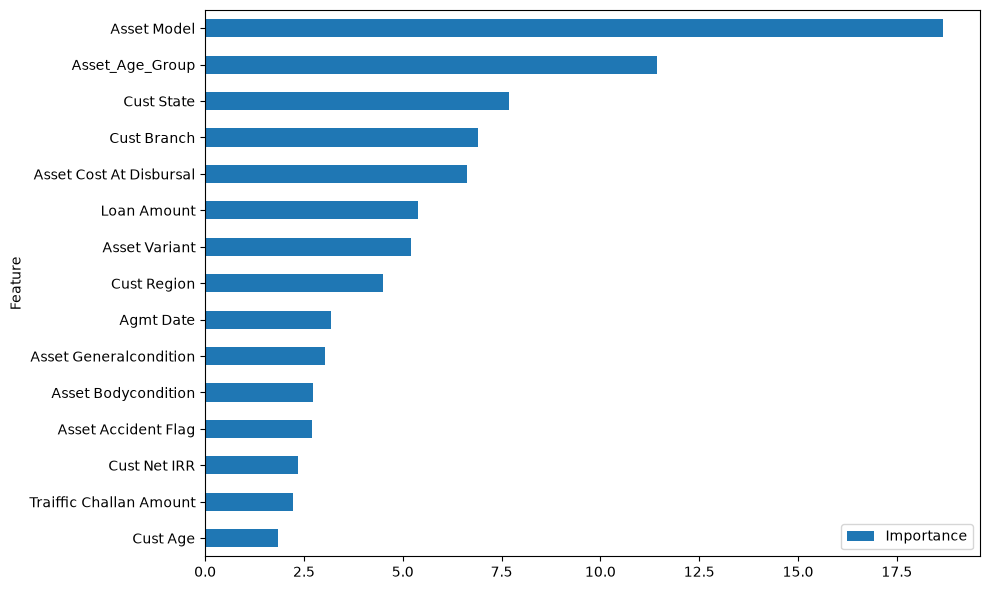

In [15]:
import matplotlib.pyplot as plt

feature_imp.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,6)
)

plt.tight_layout()
plt.show()